In [1]:
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModel,
    Trainer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    EarlyStoppingCallback,
    PreTrainedModel,
    AutoConfig,
    DataCollatorWithPadding,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import Dataset as HFDataset
from evaluate import load as load_metric
from huggingface_hub.utils import disable_progress_bars
import os
import gc
import numpy as np
from scipy.special import softmax
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from rich.console import Console
from rich.table import Table
from rich import print
import questionary
import sys

In [ ]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"

precision = torch.bfloat16
precision = torch.float32
device = "cuda:0" if torch.cuda.is_available() else "cpu"
model_name = 'nickprock/setfit-italian-hate-speech'
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [3]:
ita = pd.read_csv("dataset/augmented_it.csv")
esp = pd.read_csv("dataset/augmented_es.csv")

In [4]:
dataset = ita
dataset['bio'] = dataset['bio'].fillna('')

In [5]:
pre_train_df, pre_test_df = train_test_split(
    dataset, test_size=0.3, stratify=dataset["lgbt"], random_state=42
)

In [6]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        batch["bio"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

train_ds = HFDataset.from_pandas(pre_train_df).map(tokenize, batched=True)
test_ds = HFDataset.from_pandas(pre_test_df).map(tokenize, batched=True)
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "lgbt"], output_all_columns=True)
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "lgbt"], output_all_columns=True)

Map:   0%|          | 0/760 [00:00<?, ? examples/s]

Map:   0%|          | 0/326 [00:00<?, ? examples/s]

In [7]:
label_counts = pre_train_df["lgbt"].value_counts().to_dict()
total = sum(label_counts.values())
weights = [total / label_counts[i] for i in sorted(label_counts.keys())]
class_weights = torch.tensor(weights, dtype=torch.float)

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2, dtype=precision).to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nickprock/setfit-italian-hate-speech and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits.float()
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device).to(torch.float32))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [10]:

accuracy_metric = load_metric("accuracy")
f1_metric = load_metric("f1")

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels)["f1"],
    }

In [12]:
training_args = TrainingArguments(
    output_dir="./results_lgbt_pretrain",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs_lgbt_pretrain",
    logging_steps=50,
    save_total_limit=2,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/tmp/ipykernel_38628/2129907745.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.486400,0.416633,0.797546,0.000000
2,0.255100,0.317900,0.843558,0.370370
3,0.204100,0.271383,0.898773,0.679612
4,0.120900,0.241862,0.923313,0.778761
5,0.189700,0.242083,0.923313,0.778761
6,0.161700,0.241658,0.923313,0.778761
7,0.173100,0.240380,0.923313,0.778761
8,0.168100,0.240761,0.923313,0.778761


TrainOutput(global_step=1520, training_loss=0.20144378417416622, metrics={'train_runtime': 37.216, 'train_samples_per_second': 163.371, 'train_steps_per_second': 40.843, 'total_flos': 399928804147200.0, 'train_loss': 0.20144378417416622, 'epoch': 8.0})

In [14]:
class DualEncoderForSequenceClassification(PreTrainedModel):
    config_class = AutoConfig
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.encoder_text = AutoModel.from_config(config)
        self.encoder_bio = AutoModel.from_config(config)
        hidden_size = config.hidden_size

        self.gate_layer = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Sigmoid()
        )
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(hidden_size, config.num_labels)
        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, labels=None, return_dict=None):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        outputs_text = self.encoder_text(input_ids=input_ids, attention_mask=attention_mask, return_dict=return_dict)
        outputs_bio = self.encoder_bio(input_ids=input_ids, attention_mask=attention_mask, return_dict=return_dict)

        h_text = outputs_text.last_hidden_state[:, 0].to(torch.float32)
        h_bio = outputs_bio.last_hidden_state[:, 0].to(torch.float32)

        combined = torch.cat((h_text, h_bio), dim=-1)
        gate = self.gate_layer(combined)
        h_final = gate * h_text + (1 - gate) * h_bio

        pooled_output = self.dropout(h_final)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            class_weights = torch.tensor(self.config.class_weights, device=self.device, dtype=torch.float32) if hasattr(self.config, 'class_weights') and self.config.class_weights is not None else None
            
            loss_fct = nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        if not return_dict:
            output = (logits,)
            return ((loss,) + output) if loss is not None else output

        return SequenceClassifierOutput(loss=loss, logits=logits)

In [15]:
train_df, test_df = train_test_split(
    dataset, test_size=0.3, stratify=dataset["label"], random_state=42
)

In [16]:
train_ds = HFDataset.from_pandas(train_df).map(tokenize, batched=True)
test_ds = HFDataset.from_pandas(test_df).map(tokenize, batched=True)
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/760 [00:00<?, ? examples/s]

Map:   0%|          | 0/326 [00:00<?, ? examples/s]

In [17]:
label_counts = train_df["label"].value_counts().to_dict()
total = sum(label_counts.values())
weights = [total / label_counts[i] for i in sorted(label_counts.keys())]
class_weights = torch.tensor(weights, dtype=torch.float)

In [18]:
config = AutoConfig.from_pretrained(model_name, num_labels=2, dtype=precision)
config.class_weights = class_weights.tolist()
combined_model = DualEncoderForSequenceClassification(config)

In [19]:
base_model = AutoModel.from_pretrained(model_name, dtype=precision)
combined_model.encoder_text.load_state_dict(base_model.state_dict())

<All keys matched successfully>

In [20]:
state_dict = trainer.model.state_dict()
filtered_state_dict = {k.replace("bert.", ""): v for k, v in state_dict.items() if k.startswith("bert.")}
combined_model.encoder_bio.load_state_dict(filtered_state_dict, strict=False)

<All keys matched successfully>

In [21]:
for param in combined_model.encoder_bio.parameters():
    param.requires_grad = False

In [22]:
del trainer.model, trainer, base_model
gc.collect()
torch.cuda.empty_cache()

# Linear Probing

In [23]:
for param in combined_model.encoder_text.parameters():
    param.requires_grad = False

In [24]:
combined_model.to(device)

DualEncoderForSequenceClassification(
  (encoder_text): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31102, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((76

In [25]:
training_args = TrainingArguments(
    output_dir="./results_dual_encoder",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=4,
    num_train_epochs=8,
    weight_decay=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs_dual_encoder",
    logging_steps=50,
    save_total_limit=2,
)

trainer = Trainer(
    model=combined_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

/tmp/ipykernel_38628/2781531042.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [26]:
trainer.train()

Epoch,Training Loss,Validation Loss


TrainOutput(global_step=192, training_loss=0.39845416446526843, metrics={'train_runtime': 7.8551, 'train_samples_per_second': 774.02, 'train_steps_per_second': 48.885, 'total_flos': 404060021145600.0, 'train_loss': 0.39845416446526843, 'epoch': 4.0})

# Fine tuning

In [ ]:
# Unfreeze text pipe
for param in combined_model.encoder_text.parameters():
    param.requires_grad = True

# Unfreeze bio pipe
for param in combined_model.encoder_bio.parameters():
    param.requires_grad = False

In [28]:
training_args = TrainingArguments(
    output_dir="./results_dual_encoder",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=4,
    num_train_epochs=8,
    weight_decay=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs_dual_encoder",
    logging_steps=50,
    save_total_limit=2,
)

trainer = Trainer(
    model=combined_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

/tmp/ipykernel_38628/3102993777.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [29]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.356657,0.938650,0.841270
2,0.429900,0.326894,0.938650,0.841270
3,0.402500,0.308599,0.938650,0.841270
4,0.362600,0.294580,0.941718,0.848000
5,0.354000,0.285624,0.941718,0.848000
6,0.341100,0.280237,0.941718,0.848000
7,0.353400,0.277887,0.941718,0.848000


TrainOutput(global_step=336, training_loss=0.3666943141392299, metrics={'train_runtime': 36.666, 'train_samples_per_second': 165.821, 'train_steps_per_second': 10.473, 'total_flos': 707105037004800.0, 'train_loss': 0.3666943141392299, 'epoch': 7.0})

In [30]:
console = Console()

        Test Set Metrics         
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric             ┃    Value ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss               │   0.2946 │
│ Accuracy           │   0.9417 │
│ F1                 │   0.8480 │
│ Runtime            │   0.5222 │
│ Samples_per_second │ 624.2760 │
│ Steps_per_second   │ 157.0270 │
└────────────────────┴──────────┘

Error analysis results saved to 'error_analysis_results.csv'

Confusion Matrix:

[[254  10]
 [  9  53]]

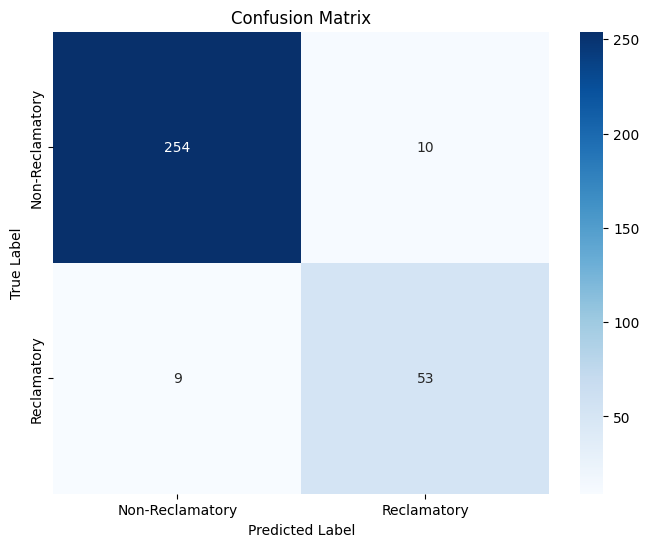

In [31]:
## Prediction and Metrics ##
predictions_output = trainer.predict(test_ds)
table = Table(title="Test Set Metrics")
table.add_column("Metric", justify="left", style="cyan", no_wrap=True)
table.add_column("Value", justify="right", style="magenta")

for k, v in predictions_output.metrics.items():
    table.add_row(k.replace("test_", "").capitalize(), f"{v:.4f}" if isinstance(v, float) else str(v))
print(table)

## Error Analysis ##
logits = predictions_output.predictions
true_labels = predictions_output.label_ids
predicted_labels = np.argmax(logits, axis=-1)
probabilities = softmax(logits, axis=1)
confidence_scores = np.max(probabilities, axis=1)

results_df = test_df.copy()
results_df['predicted_label'] = predicted_labels
results_df['true_label'] = true_labels
results_df['confidence'] = confidence_scores
results_df['is_correct'] = (results_df['true_label'] == results_df['predicted_label'])

output_filename = "error_analysis_results.csv"
results_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
console.print(f"\n[bold green]Error analysis results saved to [cyan]'{output_filename}'[/cyan][/bold green]")

## Confusion Matrix ##
console.print("\n[bold]Confusion Matrix:[/bold]")
cm = confusion_matrix(true_labels, predicted_labels)
print(cm)
class_labels = ['Non-Reclamatory', 'Reclamatory']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig("confusionmatrix.png")